# Самостоятельная работа #1
### Максимов Павел Александрович

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import random
from IPython.display import clear_output

In [ ]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_random_seed(42)

In [7]:
df = pd.read_csv('YearPredictionMSD.txt', header=None)

print(f"Размер датасета: {df.shape}")
print(f"Первые несколько строк:")
df.head()

Размер датасета: (515345, 91)
Первые несколько строк:


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [8]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.8 * len(X))
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

print(f"Размер обучающей выборки: {X_train.shape}, {y_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}, {y_test.shape}")
print(f"Диапазон годов в обучающей выборке: {y_train.min()} - {y_train.max()}")
print(f"Диапазон годов в тестовой выборке: {y_test.min()} - {y_test.max()}")

Размер обучающей выборки: (412276, 90), (412276,)
Размер тестовой выборки: (103069, 90), (103069,)
Диапазон годов в обучающей выборке: 1922 - 2011
Диапазон годов в тестовой выборке: 1925 - 2010


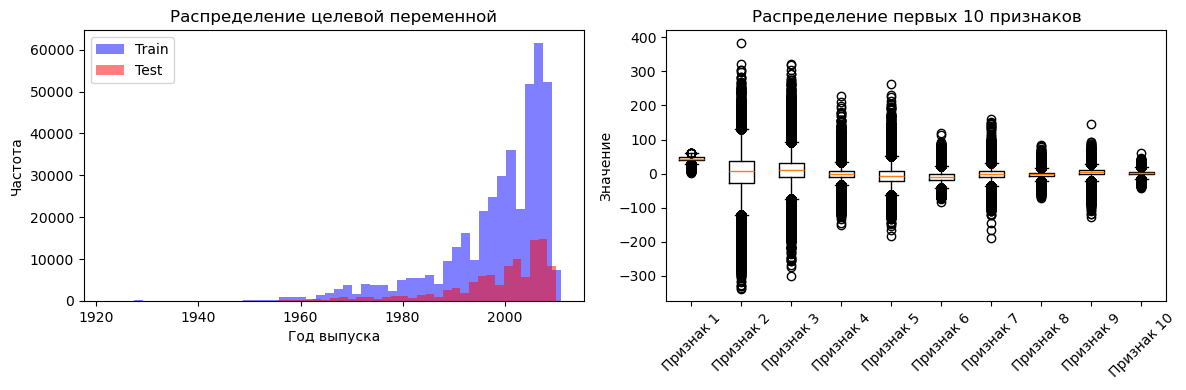

Среднее значение целевой переменной (train): 1998.36
Среднее значение целевой переменной (test): 1998.53
Стандартное отклонение (train): 10.97
Стандартное отклонение (test): 10.77


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, alpha=0.5, label='Train', color='blue')
axes[0].hist(y_test, bins=50, alpha=0.5, label='Test', color='red')
axes[0].set_xlabel('Год выпуска')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение целевой переменной')
axes[0].legend()

axes[1].boxplot([X_train[:, i] for i in range(min(10, X_train.shape[1]))], 
                tick_labels=[f'Признак {i+1}' for i in range(min(10, X_train.shape[1]))])
axes[1].set_ylabel('Значение')
axes[1].set_title('Распределение первых 10 признаков')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Среднее значение целевой переменной (train): {y_train.mean():.2f}")
print(f"Среднее значение целевой переменной (test): {y_test.mean():.2f}")
print(f"Стандартное отклонение (train): {y_train.std():.2f}")
print(f"Стандартное отклонение (test): {y_test.std():.2f}")

In [11]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"Признаки после масштабирования:")
print(f"  Train: mean={X_train_scaled.mean(axis=0)[:5]}, std={X_train_scaled.std(axis=0)[:5]}")
print(f"  Test: mean={X_test_scaled.mean(axis=0)[:5]}, std={X_test_scaled.std(axis=0)[:5]}")
print(f"\nЦелевая переменная после нормировки:")
print(f"  Train: mean={y_train_scaled.mean():.6f}, std={y_train_scaled.std():.6f}")
print(f"  Test: mean={y_test_scaled.mean():.6f}, std={y_test_scaled.std():.6f}")

Признаки после масштабирования:
  Train: mean=[ 1.17057657e-16 -1.54422351e-17  6.05969850e-17 -7.03173205e-18
 -6.21825716e-17], std=[1. 1. 1. 1. 1.]
  Test: mean=[ 0.02404509  0.02332154 -0.01181593  0.02406394 -0.01426816], std=[0.96841707 0.98765348 1.0007616  0.99485331 0.99992787]

Целевая переменная после нормировки:
  Train: mean=0.000000, std=1.000000
  Test: mean=0.014688, std=0.981889


In [12]:
class YearDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256
train_dataset = YearDataset(X_train_scaled, y_train_scaled)
test_dataset = YearDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Количество батчей в обучающей выборке: {len(train_loader)}")
print(f"Количество батчей в тестовой выборке: {len(test_loader)}")

Количество батчей в обучающей выборке: 1611
Количество батчей в тестовой выборке: 403


In [13]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64, 32]):
        super(LinearRegressionModel, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 1))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x).squeeze()

input_size = X_train_scaled.shape[1]
model = LinearRegressionModel(input_size, hidden_sizes=[128, 64, 32])

print(f"Модель:")
print(model)
print(f"\nКоличество параметров: {sum(p.numel() for p in model.parameters())}")

Модель:
LinearRegressionModel(
  (model): Sequential(
    (0): Linear(in_features=90, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Количество параметров: 22017


In [20]:
import platform

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Используемое устройство: CUDA")
# У меня макбук на арм, поэтому локально при обучении буду использовать MPS
elif torch.backends.mps.is_available() and platform.machine() == "arm64":
    device = torch.device("mps")
    print("Используемое устройство: MPS (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("Используемое устройство: CPU")

model = model.to(device)

Используемое устройство: MPS (Apple Silicon)


In [24]:
def mse_loss(pred, tar):
    return ((pred - tar) ** 2).mean()

def rmse(pred, tar):
    return torch.sqrt(((pred - tar) ** 2).mean())

In [23]:
def gradient_descent_step(model, lr):
    with torch.no_grad():
        for param in model.parameters():
            if param.grad is not None:
                param.data -= lr * param.grad
                param.grad.zero_()

In [25]:
def evaluate_model(model, data_loader, device, scaler_y):
    model.eval()
    total_loss = 0
    total_rmse = 0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred_scaled = model(X_batch)
                    
            y_pred = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_batch.cpu().numpy().reshape(-1, 1)).flatten()
            
            y_pred_tensor = torch.FloatTensor(y_pred).to(device)
            y_true_tensor = torch.FloatTensor(y_true).to(device)
            
            batch_loss = mse_loss(y_pred_tensor, y_true_tensor)
            batch_rmse = rmse(y_pred_tensor, y_true_tensor)
            
            total_loss += batch_loss.item() * len(X_batch)
            total_rmse += batch_rmse.item() * len(X_batch)
            total_samples += len(X_batch)
    
    model.train()
    return total_loss / total_samples, total_rmse / total_samples

In [52]:
learning_rate = 0.01 #В процессе экспериментов выяснил, что это возможно одно из наиболее оптимальных значений
num_epochs = 10

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

model.apply(init_weights)

train_losses = []
test_losses = []
train_rmses = []
test_rmses = []

print("Подготовка модели к обучению")
print(f"Learning rate: {learning_rate}")
print(f"Количество эпох: {num_epochs}")
print(f"Размер батча: {batch_size}")

Подготовка модели к обучению
Learning rate: 0.01
Количество эпох: 10
Размер батча: 256


In [53]:
for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    epoch_train_rmse = 0
    num_batches = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for batch_idx, (X_batch, y_batch) in enumerate(progress_bar):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        for param in model.parameters():
            if param.grad is not None:
                param.grad.zero_()
        
        y_pred_scaled = model(X_batch)
        
        loss = mse_loss(y_pred_scaled, y_batch)
        
        loss.backward()
        
        gradient_descent_step(model, learning_rate)
        
        with torch.no_grad():
            y_pred = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_batch.cpu().numpy().reshape(-1, 1)).flatten()
            
            y_pred_tensor = torch.FloatTensor(y_pred).to(device)
            y_true_tensor = torch.FloatTensor(y_true).to(device)
            
            batch_rmse = rmse(y_pred_tensor, y_true_tensor)
            
            epoch_train_loss += loss.item()
            epoch_train_rmse += batch_rmse.item()
            num_batches += 1
        
        if batch_idx % 100 == 0:
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'rmse': f'{batch_rmse.item():.4f}'
            })
    
    avg_train_loss = epoch_train_loss / num_batches
    avg_train_rmse = epoch_train_rmse / num_batches
    
    test_loss, test_rmse = evaluate_model(model, test_loader, device, scaler_y)
    
    train_losses.append(avg_train_loss)
    test_losses.append(test_loss)
    train_rmses.append(avg_train_rmse)
    test_rmses.append(test_rmse)
    
    print(f'\nЭпоха {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {avg_train_loss:.4f}, Train RMSE: {avg_train_rmse:.4f}')
    print(f'  Test Loss: {test_loss:.4f}, Test RMSE: {test_rmse:.4f}')

Epoch 1/10: 100%|██████████| 1611/1611 [00:10<00:00, 154.41it/s, loss=0.7009, rmse=9.1844] 



Эпоха 1/10:
  Train Loss: 0.7932, Train RMSE: 9.7357
  Test Loss: 85.8487, Test RMSE: 8.8803


Epoch 2/10: 100%|██████████| 1611/1611 [00:11<00:00, 138.61it/s, loss=0.6636, rmse=8.9365]



Эпоха 2/10:
  Train Loss: 0.7090, Train RMSE: 9.2108
  Test Loss: 82.3157, Test RMSE: 8.6879


Epoch 3/10: 100%|██████████| 1611/1611 [00:10<00:00, 153.48it/s, loss=0.5018, rmse=7.7709]


...


Эпоха 8/10:
  Train Loss: 0.6408, Train RMSE: 8.7570
  Test Loss: 77.8528, Test RMSE: 8.4623


Epoch 9/10: 100%|██████████| 1611/1611 [00:10<00:00, 159.49it/s, loss=0.5525, rmse=8.1543]



Эпоха 9/10:
  Train Loss: 0.6363, Train RMSE: 8.7268
  Test Loss: 77.5379, Test RMSE: 8.4314


Epoch 10/10: 100%|██████████| 1611/1611 [00:10<00:00, 158.89it/s, loss=0.5710, rmse=8.2895] 



Эпоха 10/10:
  Train Loss: 0.6323, Train RMSE: 8.6974
  Test Loss: 77.3866, Test RMSE: 8.3968


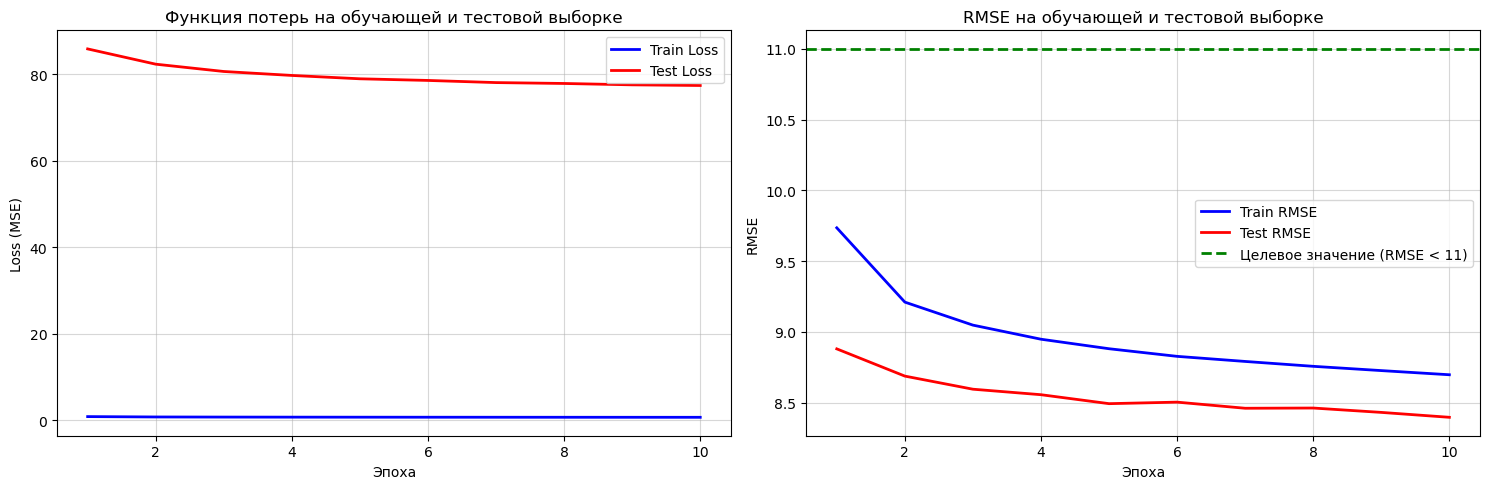

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ

Train Loss (MSE): 0.6323
Test Loss (MSE): 77.3866
Train RMSE: 8.6974
Test RMSE: 8.3968

Цель достигнута!) Test RMSE = 8.3968 < 11


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(range(1, num_epochs + 1), train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(range(1, num_epochs + 1), test_losses, 'r-', label='Test Loss', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Функция потерь на обучающей и тестовой выборке')
axes[0].legend()
axes[0].grid(True, alpha=0.5)

axes[1].plot(range(1, num_epochs + 1), train_rmses, 'b-', label='Train RMSE', linewidth=2)
axes[1].plot(range(1, num_epochs + 1), test_rmses, 'r-', label='Test RMSE', linewidth=2)
axes[1].axhline(y=11, color='g', linestyle='--', label='Целевое значение (RMSE < 11)', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE на обучающей и тестовой выборке')
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print(f"\nTrain Loss (MSE): {train_losses[-1]:.4f}")
print(f"Test Loss (MSE): {test_losses[-1]:.4f}")
print(f"Train RMSE: {train_rmses[-1]:.4f}")
print(f"Test RMSE: {test_rmses[-1]:.4f}")

if test_rmses[-1] < 11:
    print(f"\nЦель достигнута!) Test RMSE = {test_rmses[-1]:.4f} < 11")
else:
    print(f"Цель не достигнута( Test RMSE = {test_rmses[-1]:.4f} >= 11")

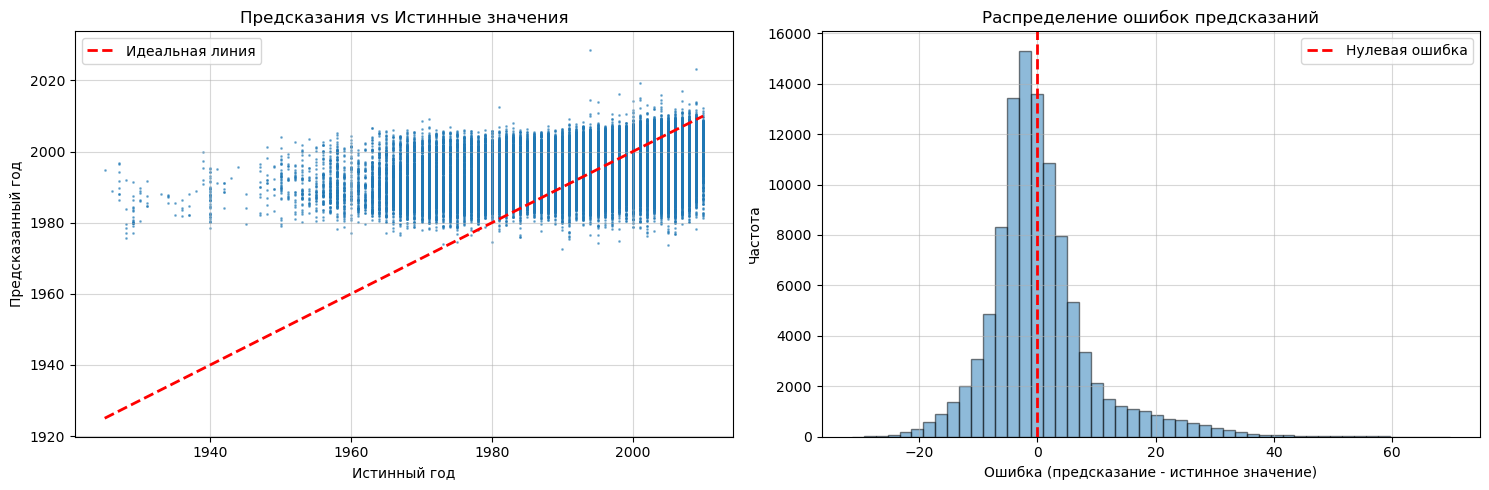


Статистика ошибок:
  Средняя ошибка: 0.3663
  Медианная ошибка: -0.9043
  Стандартное отклонение ошибок: 8.7893
  MAE: 6.0374


In [56]:
# Чисто ради интереса дополнительные графики сравнения предсказаний с истинными значениями и распределение ошибок
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        y_pred_scaled = model(X_batch)
        
        y_pred = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1)).flatten()
        y_true = scaler_y.inverse_transform(y_batch.cpu().numpy().reshape(-1, 1)).flatten()
        
        all_predictions.extend(y_pred)
        all_targets.extend(y_true)

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(all_targets, all_predictions, alpha=0.5, s=1)
axes[0].plot([all_targets.min(), all_targets.max()], 
             [all_targets.min(), all_targets.max()], 
             'r--', linewidth=2, label='Идеальная линия')
axes[0].set_xlabel('Истинный год')
axes[0].set_ylabel('Предсказанный год')
axes[0].set_title('Предсказания vs Истинные значения')
axes[0].legend()
axes[0].grid(True, alpha=0.5)

errors = all_predictions - all_targets
axes[1].hist(errors, bins=50, alpha=0.5, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Нулевая ошибка')
axes[1].set_xlabel('Ошибка (предсказание - истинное значение)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ошибок предсказаний')
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nСтатистика ошибок:")
print(f"  Средняя ошибка: {errors.mean():.4f}")
print(f"  Медианная ошибка: {np.median(errors):.4f}")
print(f"  Стандартное отклонение ошибок: {errors.std():.4f}")
print(f"  MAE: {np.abs(errors).mean():.4f}")
